# Sequential fits

*Written by Claude Code, Anthropic's coding agent, for the rietx project.*

An in-situ experiment measures one specimen many times while something changes: temperature, time, pressure, gas.
rietx fits such a series pattern by pattern, starting each fit from the answer before it.
That warm start makes each fit fast, but it also means a mistake can travel down the chain.
We fit a synthetic heating ramp whose answer we know, then break it twice to see what the series reports.

**You need** rietx 1.7 or later, which the next cell installs.
Notebook 02 introduces plans and a single refinement.

**Runtime** is under a minute on a laptop.

In [ ]:
%pip install rietx

## A synthetic heating ramp

The specimen is LaB₆ on a synchrotron capillary instrument.
Its cell expands by 0.05 % per 100 K from 300 K to 900 K.
We write the structure as a short CIF and make each pattern from the true model with Poisson noise.

In [1]:
import csv
import re
import tempfile
from pathlib import Path

import numpy as np

import rietx as rx

work = Path(tempfile.mkdtemp())
cif = work / "LaB6.cif"
cif.write_text(
    "data_LaB6\n_space_group_name_H-M_alt 'P m -3 m'\n"
    + "".join(f"_cell_length_{k} 4.1566\n" for k in "abc")
    + "".join(f"_cell_angle_{k} 90\n" for k in ("alpha", "beta", "gamma"))
    + "loop_\n_atom_site_label\n_atom_site_type_symbol\n_atom_site_fract_x\n"
      "_atom_site_fract_y\n_atom_site_fract_z\n_atom_site_B_iso_or_equiv\n"
      "La1 La 0 0 0 0.4\nB1 B 0.1996 0.5 0.5 0.4\n",
    encoding="utf-8")
lab6 = rx.Structure.from_cif(cif)

TEMPERATURES = [300, 400, 500, 600, 700, 800, 900]
A0, EXPANSION = 4.1566, 5e-4               # Å at 300 K, and the fraction per step
TRUE_A = [A0 * (1 + EXPANSION * k) for k in range(len(TEMPERATURES))]

true_instrument = rx.Instrument.debye_scherrer(wavelength=0.4139)
true_instrument.zero_shift.value = 0.008
true_instrument.profile.w.value = 2.5e-4
true_instrument.background = rx.BackgroundChebyshev.with_terms(3)
for coefficient, value in zip(true_instrument.background.coefficients, (40.0, -6.0, 1.5)):
    coefficient.value = value
two_theta = np.arange(3.0, 24.0, 0.005)


def simulate(a, seed):
    """One pattern of the true specimen at cell edge a."""
    structure = lab6.model_copy(deep=True)
    for edge in "abc":
        getattr(structure.phases[0].cell, edge).value = a
    structure.phases[0].scale.value = 5e-4
    y = rx.Refinement(structure, true_instrument).predict(two_theta)
    counts = np.random.default_rng(seed).poisson(np.maximum(y, 1.0)).astype(float)
    return rx.PatternData(two_theta=two_theta, intensity=counts)


patterns = [simulate(a, seed=11 + k) for k, a in enumerate(TRUE_A)]

The starting model is what you would have before the first fit: the cell 0.1 % off, no zero shift, and peaks 50 % too wide.

In [2]:
def starting_model():
    structure = lab6.model_copy(deep=True)
    for edge in "abc":
        getattr(structure.phases[0].cell, edge).value = A0 * 1.001
    instrument = rx.Instrument.debye_scherrer(wavelength=0.4139)
    instrument.profile.w.value = 2.5e-4 * 1.5
    instrument.background = rx.BackgroundChebyshev.with_terms(3)
    return structure, instrument


LABELS = [f"{t} K" for t in TEMPERATURES]

## A series is a list of patterns

`refine_sequential` takes the series as an ordinary Python list of `PatternData`, one per measurement, in the order to fit them.
`x` is a list of the same length giving each pattern's place along the series (temperature here), and `labels` names each one.
Nothing else ties them together, so the order of the list is the order of the chain.

In [3]:
print(type(patterns).__name__, len(patterns), type(patterns[0]).__name__)
print(patterns[0])

list 7 PatternData
PatternData of 4200 points, 3–23.995° 2θ, median step 0.005°
  intensity: <4200 floats 19…149878>
  sigma: None
  excluded_regions: none
  metadata: none


## Loading a real series from files

A real series arrives as a folder of files, and the work is putting them in the right order with the right temperature.
Here we write our synthetic patterns out as an instrument might, numbered by scan, with the temperatures in a separate log.

In [4]:
folder = work / "ramp"
folder.mkdir()
for scan, (pattern, temperature) in enumerate(zip(patterns, TEMPERATURES), start=8):
    rows = "".join(f"{t:.4f} {y:.0f}\n" for t, y in zip(pattern.two_theta, pattern.intensity))
    (folder / f"scan{scan}.xy").write_text(rows, encoding="utf-8")
log = "scan,temperature_K\n" + "".join(
    f"{scan},{t}\n" for scan, t in enumerate(TEMPERATURES, start=8))
(folder / "temperatures.csv").write_text(log, encoding="utf-8")

print([p.name for p in sorted(folder.glob("*.xy"))])

['scan10.xy', 'scan11.xy', 'scan12.xy', 'scan13.xy', 'scan14.xy', 'scan8.xy', 'scan9.xy']


Sorting the file names gives the wrong order: `scan10` sorts before `scan8`, because names compare as text, character by character.
Sort by the number in the name instead, and take each temperature from the log rather than assuming the order.

In [5]:
def scan_number(path):
    return int(re.search(r"\d+", path.stem).group())


files = sorted(folder.glob("*.xy"), key=scan_number)
with open(folder / "temperatures.csv", encoding="utf-8", newline="") as handle:
    temperature_of = {int(row["scan"]): float(row["temperature_K"]) for row in csv.DictReader(handle)}

loaded = [rx.read_pattern(path) for path in files]
loaded_x = [temperature_of[scan_number(path)] for path in files]
print([path.name for path in files])
print(loaded_x)

['scan8.xy', 'scan9.xy', 'scan10.xy', 'scan11.xy', 'scan12.xy', 'scan13.xy', 'scan14.xy']
[300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0]


Other naming conventions need only a different key.
When the temperature is in the file name itself, read it with a regular expression and sort on it.

In [6]:
names = ["LaB6_1000K.xye", "LaB6_300K.xye", "LaB6_650.5K.xye"]


def temperature_in_name(name):
    return float(re.search(r"([\d.]+)K", name).group(1))


print(sorted(names, key=temperature_in_name))

['LaB6_300K.xye', 'LaB6_650.5K.xye', 'LaB6_1000K.xye']


A timestamp in the name sorts correctly as text only when it is written largest unit first, as in `2026-10-07T14-05-00`.
Whatever the convention, print the sorted names and their `x` values once, as above, before fitting.

## Fit the series

`refine_sequential` fits the patterns in order, starting each fit from the parameters the previous one finished with.
The `carry` argument says which parameters pass along the chain.
It is a list of parameter-path globs, as in a plan's stages.
A parameter matching one starts each fit from the previous fit's value, and any other starts from the starting model.
`["*"]` carries everything, and it is the default, written out here.
Narrow it only when a parameter must provably not be chained.
For example, `carry=["phases.*", "instrument.zero_shift"]` would restart the background and peak widths at every pattern.

In [7]:
series = rx.refine_sequential(loaded, *starting_model(), carry=["*"], plan="mccusker_default",
                              x=loaded_x, x_label="T (K)", labels=LABELS)
print(series)

SeriesResult: 7 pattern(s), rietveld, direction=forward
  diagnostics: 2 unresolved
    INFO SEQUENTIAL_PERSISTENT_FINDING: CAPILLARY_OFFSET_UNAVAILABLE fired on instrument.geometry.goniometer_radius_mm in 7 of 7 patterns (100% of the series) — read this as a property of the model rather than of any one pattern: CAPILLARY_OFFSET_UNAVAILABLE in most of a series is the same finding repeated, and the thing to change is the model or the plan, not the individual fits. The per-pattern diagnostics carry each occurrence
    WARNING SEQUENTIAL_PERSISTENT_FINDING: PATTERN_UNDERSAMPLED fired on the fit in 7 of 7 patterns (100% of the series) — read this as a property of the model rather than of any one pattern: PATTERN_UNDERSAMPLED in most of a series is the same finding repeated, and the thing to change is the model or the plan, not the individual fits. The per-pattern diagnostics carry each occurrence
  trajectory (T (K)):
    [1/7] 300 K x=300 converged Rwp=0.0408
    [2/7] 400 K x=400 converg

Every pattern converged.
The two diagnostics are `SEQUENTIAL_PERSISTENT_FINDING`: one finding repeated in every pattern, which is a property of the model and not of any single fit.
Here they are the step size and a capillary correction this model does not use.

## The trajectory

A series answers a question about how a parameter changes.
`series.trajectory` returns one parameter across the series, with esds.

In [8]:
a = series.trajectory("phases.0.cell.a")
for label, value, esd, true in zip(a.labels, a.value, a.stderr, TRUE_A):
    print(f"{label:6} a = {value:.6f} +/- {esd:.6f} Å   true {true:.6f}   off by {(value - true) / esd:+.1f} esd")
slope = np.polyfit(TEMPERATURES, a.value, 1)[0]
print(f"fitted expansion {slope / A0:.4e} per K, true {EXPANSION / 100:.4e}")

300 K  a = 4.156602 +/- 0.000004 Å   true 4.156600   off by +0.6 esd
400 K  a = 4.158681 +/- 0.000004 Å   true 4.158678   off by +0.6 esd
500 K  a = 4.160757 +/- 0.000004 Å   true 4.160757   off by +0.1 esd
600 K  a = 4.162841 +/- 0.000004 Å   true 4.162835   off by +1.5 esd
700 K  a = 4.164909 +/- 0.000004 Å   true 4.164913   off by -1.1 esd
800 K  a = 4.166991 +/- 0.000004 Å   true 4.166991   off by -0.1 esd
900 K  a = 4.169068 +/- 0.000004 Å   true 4.169070   off by -0.5 esd
fitted expansion 4.9979e-06 per K, true 5.0000e-06


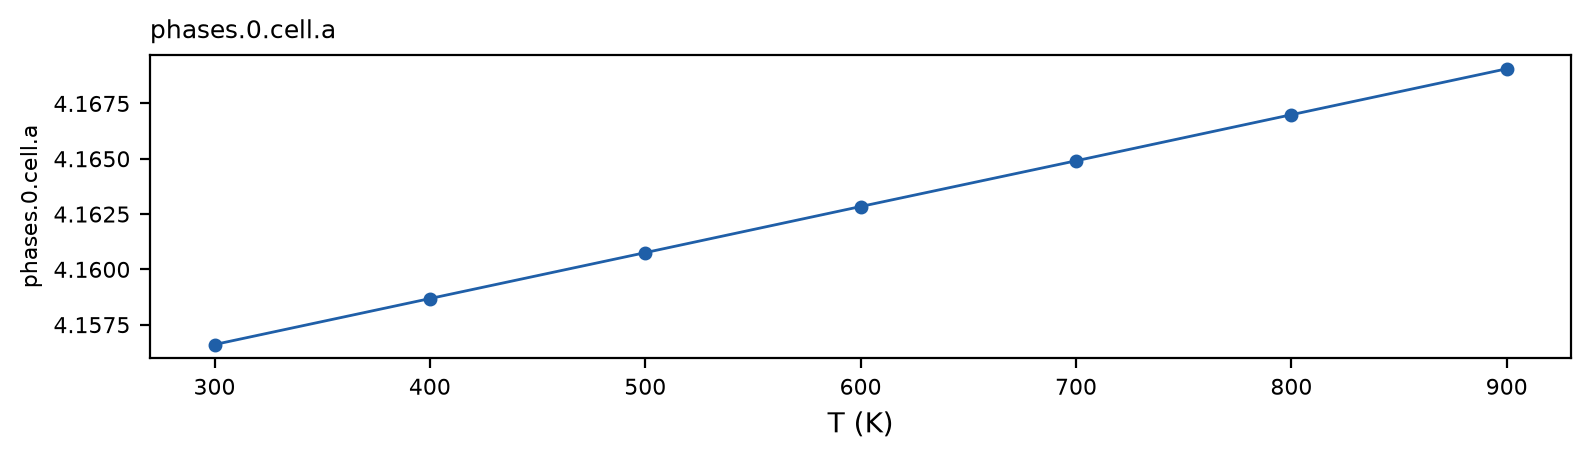

In [9]:
series.plot("phases.0.cell.a")

## Is the answer path-dependent?

A warm start means each answer depends on the one before it.
If a fit lands in a slightly wrong place, the next fit starts there.
`direction="both"` runs the chain forward and backward and compares the two.
A parameter the two directions disagree on is flagged `SEQUENTIAL_PATH_DEPENDENT`.
That check is what separates a measured trend from an artefact of the order.

In [10]:
both = rx.refine_sequential(patterns, *starting_model(), plan="mccusker_default",
                            x=TEMPERATURES, x_label="T (K)", labels=LABELS, direction="both")
print([d.code for d in both.diagnostics])

['SEQUENTIAL_PERSISTENT_FINDING', 'SEQUENTIAL_PERSISTENT_FINDING']


No `SEQUENTIAL_PATH_DEPENDENT`: both directions agree, so the trend is not an artefact of fitting from cold to hot.

## A jump in the series

Now give the 700 K pattern a cell 2 % larger than its neighbours, as a phase transition might.

In [11]:
jumped = list(patterns)
jumped[4] = simulate(TRUE_A[4] * 1.02, seed=15)
series_jump = rx.refine_sequential(jumped, *starting_model(), plan="mccusker_default",
                                   x=TEMPERATURES, x_label="T (K)", labels=LABELS)
for d in series_jump.diagnostics:
    if d.code == "SEQUENTIAL_DISCONTINUITY" and "cell.a" in d.message:
        print(f"[{d.level}] {d.code}: {d.message}")
print(series_jump.trajectory("phases.0.cell.a").value)

[info] SEQUENTIAL_DISCONTINUITY: phases.0.cell.a steps by 0.08536 between 600 K and 700 K (T (K) 600 → 700), 41× its median step over the series
[4.156602475248216, 4.158680881186243, 4.160757148371967, 4.162841149464121, 4.248201710033623, 4.166991214249426, 4.169067860698781]


The 700 K fit found the larger cell.
When a warm start fails, the series escalates: it retries in stages, then from the initial model, and keeps the best attempt.
`SEQUENTIAL_DISCONTINUITY` marks the step.
It cannot tell a real change from a failed fit, so check that pattern's own fit before reading the jump as physics.

## A frame the chain cannot fit

Make the jump 5 %, beyond what any starting point here can reach.

In [12]:
broken = list(patterns)
broken[4] = simulate(TRUE_A[4] * 1.05, seed=15)
series_broken = rx.refine_sequential(broken, *starting_model(), plan="mccusker_default",
                                     x=TEMPERATURES, x_label="T (K)", labels=LABELS)
print(series_broken)

SeriesResult: 7 pattern(s), rietveld, direction=forward
  diagnostics: 4 unresolved
    WARNING SEQUENTIAL_RWP_OUTLIER: pattern 4 (700 K) reached Rwp 0.9692 on its best rung, 19.02× the fence at 0.0510 (the reseed factor × the median Rwp of the patterns accepted before it), after every rung the chain tried (warm, warm_staged, cold); against 600 K, the last pattern before it inside the fence: GoF 26.32 to its 1.02, Rexp 0.0368 to its 0.0400 — no starting point brought this fit near its neighbours', so the pattern itself differs from them; open its own fit before reading its values.  GoF says which way: well above theirs is a model the pattern has outgrown — a specimen change the model lacks, or a bad frame; like theirs, with a higher Rexp, is fewer counts — a short or blank frame, a weaker beam — where the fit may be sound, so check that each phase is still in the pattern (a scale within a few esds of zero is one it does not contain).  The fence follows the median of the accepted patter

The 700 K pattern failed on every attempt, and `SEQUENTIAL_RWP_OUTLIER` names it.
The 800 K pattern started from that failure, so its warm start failed too.
`SEQUENTIAL_RESEED` says it was refitted from the initial model, and its answer is good.

A pattern whose fit diverges on every attempt goes further: it is quarantined (`SEQUENTIAL_UNRECOVERED`), seeds no successor and is left out of the series' statistics.
Either way the rest of the trajectory survives, and the summary says which points to distrust.

## Checking an agent's work

When an agent reports a trajectory, check these.
The rules are in the rietx agent skill (`SKILL.md` §4b, the trajectory row, and `references/series.md`).

- **Was the chain run both ways?** Without `direction="both"`, a trend can be an artefact of the fitting order.
- **Every series diagnostic.** A discontinuity, an outlier or a reseed names the patterns to look at one by one.
- **A finding in most patterns is one finding** about the model, and the thing to change is the model or the plan.
- **Each point's esd, and the precision behind the trend.** A trajectory is only as good as its worst point.